# Actionability and Recourse Methods (RQ5): Illustrative, Not Deployable

This notebook loads `results/metrics/xai_rule_methods.json`: Anchors
(precision/coverage rule extraction), counterfactual explanations
(validity/sparsity), CEM (pertinent-positive minimal-evidence size), and RISE
(randomized input sampling for explanation).

**Scope, stated up front, matching the paper's Discussion section:** these
results show that the methods work MECHANICALLY on this forecaster -- they
produce rules, counterfactuals, and minimal-evidence sets that satisfy their own
internal validity criteria on held-out instances. They do **not** establish a
deployable, transaction-cost-aware, compliance-ready recourse framework for real
trading decisions. No transaction costs, market-impact constraints, feasibility
constraints on which features a real trader could actually change, or regulatory
adverse-action requirements are modeled here. Treat every number below as
illustrative evidence that the mechanism runs, not as investment advice or a
production recourse pipeline.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

METRICS = "../results/metrics"

with open(f"{METRICS}/xai_rule_methods.json") as f:
    rule = json.load(f)

print("Keys in xai_rule_methods.json:", list(rule.keys()))

Keys in xai_rule_methods.json: ['anchors', 'counterfactual', 'cem', 'rise']


## Anchors: rule-based sufficient conditions

An Anchor is a minimal if-then rule (a conjunction of feature-value conditions)
that, when it holds, predicts the model's output with at least `target_precision`
confidence on similar instances. We report mean precision, mean coverage (the
fraction of the input distribution the rule applies to), and how many of the 25
scored instances actually reached the 95% target precision.

In [2]:
a = rule["anchors"]
print(f"n_instances explained: {a['n_instances']}")
print(f"target precision: {a['target_precision']}, min coverage stop: {a['min_coverage_stop']}")
print(f"mean precision achieved: {a['mean_precision']:.3f}")
print(f"mean coverage: {a['mean_coverage']:.4f}  (rules apply to a small, local slice of the input space)")
print(f"mean rule length: {a['mean_rule_len']:.2f} conditions")
print(f"% of instances reaching the {a['target_precision']} target precision: {a['pct_reaching_target_precision']*100:.0f}%")
print()
print("Example anchor rules (feature conditions -> precision, coverage):")
examples = pd.DataFrame(a["examples"])
examples

n_instances explained: 25
target precision: 0.95, min coverage stop: 0.02
mean precision achieved: 0.923
mean coverage: 0.0353  (rules apply to a small, local slice of the input space)
mean rule length: 1.72 conditions
% of instances reaching the 0.95 target precision: 68%

Example anchor rules (feature conditions -> precision, coverage):


,rule_len,precision,coverage,features
0,1,0.980000,0.100006,[gt_signal_nl]
1,2,0.656667,0.010496,"[gt_signal, gt_signal_weak]"
2,2,1.000000,0.010099,"[gt_signal, gt_signal_nl]"
3,2,0.756667,0.010575,"[gt_signal, vol_roll5]"
4,2,0.986667,0.009905,"[gt_signal_nl, gt_signal]"


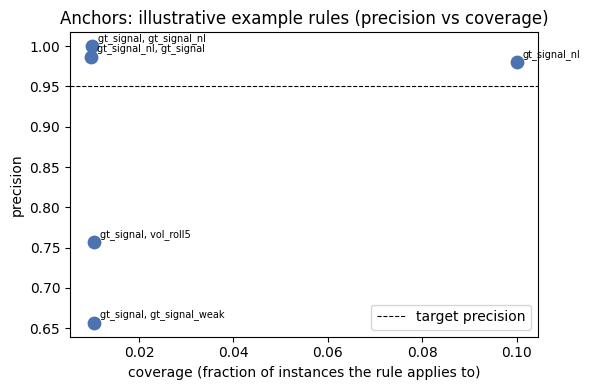

Note the classic precision/coverage trade-off: rules mentioning the injected
ground-truth signal features (gt_signal, gt_signal_nl) tend toward high precision
at very low coverage -- exactly what we'd hope an XAI method surfaces given the
known ground truth, but this alone does not make the rule an actionable trading signal.


In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(examples["coverage"], examples["precision"], s=80, color="#4C72B0")
for _, r in examples.iterrows():
    ax.annotate(", ".join(r["features"]), (r["coverage"], r["precision"]), fontsize=7,
                xytext=(4, 4), textcoords="offset points")
ax.axhline(a["target_precision"], color="black", linestyle="--", linewidth=0.8, label="target precision")
ax.set_xlabel("coverage (fraction of instances the rule applies to)")
ax.set_ylabel("precision")
ax.set_title("Anchors: illustrative example rules (precision vs coverage)")
ax.legend()
plt.tight_layout()
plt.savefig("/tmp/fig_anchors_repro.png", dpi=120)
plt.show()
print("Note the classic precision/coverage trade-off: rules mentioning the injected")
print("ground-truth signal features (gt_signal, gt_signal_nl) tend toward high precision")
print("at very low coverage -- exactly what we'd hope an XAI method surfaces given the")
print("known ground truth, but this alone does not make the rule an actionable trading signal.")

## Counterfactual explanations: validity and sparsity

A counterfactual for an instance is the smallest feature perturbation, within a
bounded search budget, that flips the model's prediction. We report validity
(fraction of instances for which a valid counterfactual was found within budget)
and mean sparsity (number of features changed).

In [4]:
cf = rule["counterfactual"]
print(f"n_instances: {cf['n_instances']}, max features-changed budget: {cf['max_features_changed_budget']}")
print(f"validity: {cf['validity']*100:.1f}% of instances found a valid flipping counterfactual within budget")
print(f"mean sparsity: {cf['mean_sparsity_features_changed']:.2f} features changed on average")
print()
print("Illustrative reading: on this synthetic-ground-truth-augmented forecaster, flipping the")
print("prediction typically requires changing just over 1 feature -- consistent with a few")
print("features (including the injected ground-truth signal) dominating the decision boundary.")
print("This is a property of THIS benchmark model, not evidence that 1-2 feature changes are")
print("achievable or meaningful for a real trader/investor in a live market.")

n_instances: 30, max features-changed budget: 6
validity: 100.0% of instances found a valid flipping counterfactual within budget
mean sparsity: 1.27 features changed on average

Illustrative reading: on this synthetic-ground-truth-augmented forecaster, flipping the
prediction typically requires changing just over 1 feature -- consistent with a few
features (including the injected ground-truth signal) dominating the decision boundary.
This is a property of THIS benchmark model, not evidence that 1-2 feature changes are
achievable or meaningful for a real trader/investor in a live market.


## CEM: pertinent-positive minimal evidence

The Contrastive Explanation Method's pertinent-positive (PP) explanation finds
the smallest subset of an instance's OWN features that is sufficient, on its
own, to preserve the model's prediction (in effect, "explains what's already
there"). Its pertinent-negative is exactly the counterfactual above.

In [5]:
cem = rule["cem"]
print(f"n_instances: {cem['n_instances']}, n_total_features: {cem['n_total_features']}")
print(f"pertinent-positive mean size: {cem['pertinent_positive_mean_size']:.3f} features "
      f"(out of {cem['n_total_features']})")
print(f"pertinent-positive median size: {cem['pertinent_positive_median_size']}")
print()
print("A mean PP size well under 1 feature (median 0) means the minimal sufficient evidence")
print("set is usually empty or a single feature -- again a property of this specific,")
print("synthetic-signal-dominated benchmark model, illustrative of the mechanism only.")
print()
print("Pertinent-negative note (from file):", cem["pertinent_negative"]["note"])

n_instances: 30, n_total_features: 28
pertinent-positive mean size: 0.133 features (out of 28)
pertinent-positive median size: 0.0

A mean PP size well under 1 feature (median 0) means the minimal sufficient evidence
set is usually empty or a single feature -- again a property of this specific,
synthetic-signal-dominated benchmark model, illustrative of the mechanism only.

Pertinent-negative note (from file): pertinent negative = minimal-change counterfactual, see the 'counterfactual' key


## RISE: randomized input sampling for explanation

RISE estimates feature importance by masking random subsets of the input and
correlating mask patterns with the change in model output; no gradient or model
internals are required.

In [6]:
r = rule["rise"]
print(f"n_instances: {r['n_instances']}, masks per instance: {r['n_masks_per_instance']}, "
      f"mask keep-prob: {r['mask_keep_prob']}")
print(f"sentiment attribution share: {r['sentiment_attribution_share']*100:.1f}%")
print()
top10 = pd.Series(r["top10"], name="importance").sort_values(ascending=False)
print("Top-10 features by RISE importance:")
print(top10)

n_instances: 40, masks per instance: 700, mask keep-prob: 0.5
sentiment attribution share: 16.9%

Top-10 features by RISE importance:
gt_signal_nl      0.04680
gt_signal         0.03263
gt_signal_weak    0.01311
co_ret            0.00689
logvol            0.00663
vol_roll20        0.00631
ret_lag5          0.00544
vol_roll5         0.00489
ret_lag3          0.00436
news_roll5        0.00435
Name: importance, dtype: float64


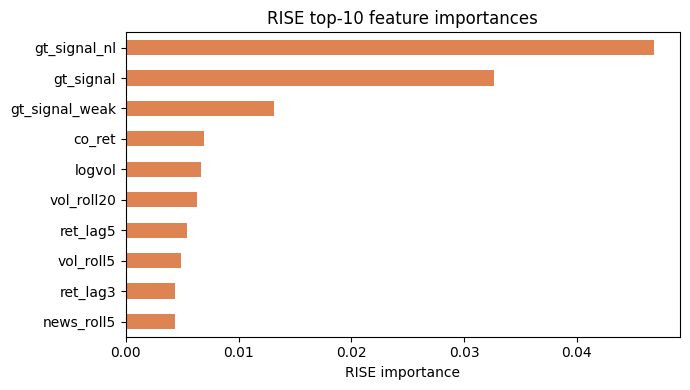

RISE faithfulness check: signal_rank=2, noise_rank=27 out of 28 features
ranks_signal_above_noise: True
ranks_nonlinear_signal_above_noise: True
redundant copy credit share: 0.368


In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
top10.sort_values().plot.barh(ax=ax, color="#DD8452")
ax.set_xlabel("RISE importance")
ax.set_title("RISE top-10 feature importances")
plt.tight_layout()
plt.savefig("/tmp/fig_rise_repro.png", dpi=120)
plt.show()

f = r["faithfulness"]
print(f"RISE faithfulness check: signal_rank={f['signal_rank']}, noise_rank={f['noise_rank']} "
      f"out of {f['n_features']} features")
print(f"ranks_signal_above_noise: {f['ranks_signal_above_noise']}")
if "ranks_nonlinear_signal_above_noise" in f:
    print(f"ranks_nonlinear_signal_above_noise: {f['ranks_nonlinear_signal_above_noise']}")
print(f"redundant copy credit share: {f.get('redundant_copy_credit_share'):.3f}")

## Summary: what these results do and do not support

**Do support:** Anchors, counterfactuals, CEM, and RISE all run successfully on
this forecaster, produce internally-valid outputs by their own criteria (Anchors
mostly reach target precision at low coverage; counterfactuals are 100% valid
within budget; CEM finds compact pertinent-positive sets; RISE ranks the
injected ground-truth signal above noise, same as the core 4 attribution
methods in notebook 30).

**Do not support:** any claim of a deployable, transaction-cost-aware,
compliance-ready recourse framework. None of these methods account for
feasibility of the suggested feature changes for a real trader, transaction
costs or market-impact of "acting on" a counterfactual, regulatory
adverse-action-notice requirements, or robustness of the recourse to model
retraining. This is exactly the framing used in the paper's Discussion section:
RQ5 results are illustrative evidence the mechanisms work, not a recourse
product.